In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, log_loss

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [5]:
# File paths (adjust if needed)
X_TRAIN_ORIG = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_train_final_v2.csv"
X_TRAIN_PCA  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/04 - PCA/X_train_pca.csv"
X_TRAIN_SMOTE = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/X_train_smote.csv"
Y_TRAIN = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_train.csv"
Y_TRAIN_SMOTE = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/y_train_smote.csv"
X_TEST_ORIG  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_test_final_v2.csv"
X_TEST_PCA   = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/04 - PCA/X_test_pca.csv"
Y_TEST = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_test.csv"
CLASS_WEIGHTS_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/class_weights.pkl"

# Output model filenames
MLP_ORIG_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/mlp_original.pkl"
MLP_PCA_OUT  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/mlp_pca.pkl"
MLP_SMOTE_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/mlp_smote.pkl"
GB_ORIG_OUT  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/gb_original.pkl"
GB_SMOTE_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/gb_smote.pkl"

# Results / plots
NN_GB_RESULTS = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/nn_gb_results.csv"
VALIDATION_METRICS = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/validation_metrics.csv"
TRAINING_CURVES = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/training_curves.png"

RANDOM_STATE = 42

In [6]:
# Load datasets
X_train_orig = pd.read_csv(X_TRAIN_ORIG)
X_train_pca  = pd.read_csv(X_TRAIN_PCA)
X_train_smote = pd.read_csv(X_TRAIN_SMOTE)

y_train_df = pd.read_csv(Y_TRAIN)
y_train = y_train_df.iloc[:,0] if y_train_df.shape[1]==1 else y_train_df["BRIDGE_CONDITION"]

y_train_smote_df = pd.read_csv(Y_TRAIN_SMOTE)
y_train_smote = y_train_smote_df.iloc[:,0] if y_train_smote_df.shape[1]==1 else y_train_smote_df["BRIDGE_CONDITION"]

X_test_orig = pd.read_csv(X_TEST_ORIG)
X_test_pca = pd.read_csv(X_TEST_PCA)
y_test_df = pd.read_csv(Y_TEST)
y_test = y_test_df.iloc[:,0] if y_test_df.shape[1]==1 else y_test_df["BRIDGE_CONDITION"]

print("Shapes:")
print(" X_train_orig:", X_train_orig.shape, " X_train_pca:", X_train_pca.shape, " X_train_smote:", X_train_smote.shape)
print(" y_train:", y_train.shape, " y_train_smote:", y_train_smote.shape)
print(" X_test_orig:", X_test_orig.shape, " X_test_pca:", X_test_pca.shape, " y_test:", y_test.shape)

# load or compute class weights (used for GB original training)
try:
    class_weights = joblib.load(CLASS_WEIGHTS_PATH)
    print("Loaded class_weights:", class_weights)
except Exception as e:
    from sklearn.utils import class_weight
    classes = np.unique(y_train)
    weights_arr = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights_arr))
    print("Computed class_weights fallback:", class_weights)


Shapes:
 X_train_orig: (1236125, 102)  X_train_pca: (1236125, 74)  X_train_smote: (1351982, 102)
 y_train: (1236125,)  y_train_smote: (1351982,)
 X_test_orig: (624193, 102)  X_test_pca: (624193, 74)  y_test: (624193,)
Loaded class_weights: {'F': np.float64(0.6797785773717117), 'G': np.float64(0.7548748933602765), 'P': np.float64(4.896921510602981)}


In [7]:
# Preprocessing: scaling for NN (fit on original train only)
scaler_orig = StandardScaler()
X_train_orig_scaled = scaler_orig.fit_transform(X_train_orig)
X_test_orig_scaled = scaler_orig.transform(X_test_orig)

scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled = scaler_pca.transform(X_test_pca)

scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
# For test with SMOTE model we still evaluate on original test (scaled by orig scaler), not on SMOTE test.
# Save scalers for reproducibility
joblib.dump(scaler_orig, "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/scaler_orig.pkl")
joblib.dump(scaler_pca, "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/scaler_pca.pkl")
joblib.dump(scaler_smote, "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/scaler_smote.pkl")
print("Scalers saved.")


Scalers saved.


Why label-encode before training MLP?
MLPClassifier uses internal numeric checks during early-stopping validation that call np.isnan on predicted arrays. If class labels are strings (object dtype), that check triggers a TypeError. Encoding labels to integers prevents this and is standard practice for neural-network pipelines. We save a LabelEncoder so we can map predictions back to original labels for evaluation.

In [9]:
# === Fix for MLP early-stopping TypeError: label-encoding + retrain MLPs ===
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from time import time

# 1) Fit LabelEncoder on original training labels (and save)
le = LabelEncoder()
le.fit(y_train)  # uses original label set (covers classes)
joblib.dump(le, "label_encoder.pkl")
print("Saved LabelEncoder (classes):", le.classes_)

# 2) Transform labels to integer-encoded arrays
y_train_enc = le.transform(y_train)
y_train_smote_enc = le.transform(y_train_smote)
y_test_enc = le.transform(y_test)  # for evaluation later

# 3) Recreate MLPClassifier instances (same hyperparams as before)
mlp_orig = MLPClassifier(hidden_layer_sizes=(128,64),
                         activation="relu",
                         solver="adam",
                         early_stopping=True,
                         validation_fraction=0.1,
                         n_iter_no_change=10,
                         max_iter=200,
                         random_state=42,
                         verbose=True)

mlp_pca = MLPClassifier(hidden_layer_sizes=(128,64),
                        activation="relu",
                        solver="adam",
                        early_stopping=True,
                        validation_fraction=0.1,
                        n_iter_no_change=10,
                        max_iter=200,
                        random_state=42,
                        verbose=True)

mlp_smote = MLPClassifier(hidden_layer_sizes=(128,64),
                          activation="relu",
                          solver="adam",
                          early_stopping=True,
                          validation_fraction=0.1,
                          n_iter_no_change=10,
                          max_iter=200,
                          random_state=42,
                          verbose=True)

# 4) Fit MLP on original (use scaled X_train_orig_scaled)
t0 = time()
mlp_orig.fit(X_train_orig_scaled, y_train_enc)
print("MLP (orig) trained: time(s)=", round(time()-t0,1), "n_iter=", mlp_orig.n_iter_)

# 5) Fit MLP on PCA (use scaled X_train_pca_scaled) with same encoder
t0 = time()
mlp_pca.fit(X_train_pca_scaled, y_train_enc)
print("MLP (pca) trained: time(s)=", round(time()-t0,1), "n_iter=", mlp_pca.n_iter_)

# 6) Fit MLP on SMOTE (use scaled X_train_smote_scaled with smote labels encoded)
t0 = time()
mlp_smote.fit(X_train_smote_scaled, y_train_smote_enc)
print("MLP (smote) trained: time(s)=", round(time()-t0,1), "n_iter=", mlp_smote.n_iter_)

# 7) Save models and info
joblib.dump(mlp_orig, "mlp_original.pkl")
joblib.dump(mlp_pca, "mlp_pca.pkl")
joblib.dump(mlp_smote, "mlp_smote.pkl")

mlp_orig_info = {"loss_curve": mlp_orig.loss_curve_, "validation_scores": getattr(mlp_orig, "validation_scores_", None)}
mlp_pca_info  = {"loss_curve": mlp_pca.loss_curve_,  "validation_scores": getattr(mlp_pca, "validation_scores_", None)}
mlp_smote_info= {"loss_curve": mlp_smote.loss_curve_, "validation_scores": getattr(mlp_smote, "validation_scores_", None)}

joblib.dump(mlp_orig_info, "mlp_orig_info.pkl")
joblib.dump(mlp_pca_info, "mlp_pca_info.pkl")
joblib.dump(mlp_smote_info, "mlp_smote_info.pkl")

print("Saved MLP models and info.")


Saved LabelEncoder (classes): ['F' 'G' 'P']
Iteration 1, loss = 0.57563795
Validation score: 0.756223
Iteration 2, loss = 0.53472877
Validation score: 0.761667
Iteration 3, loss = 0.52117196
Validation score: 0.765559
Iteration 4, loss = 0.51283429
Validation score: 0.769733
Iteration 5, loss = 0.50713835
Validation score: 0.769959
Iteration 6, loss = 0.50285710
Validation score: 0.771068
Iteration 7, loss = 0.49932990
Validation score: 0.773535
Iteration 8, loss = 0.49635770
Validation score: 0.773592
Iteration 9, loss = 0.49399555
Validation score: 0.772354
Iteration 10, loss = 0.49179427
Validation score: 0.773802
Iteration 11, loss = 0.49010369
Validation score: 0.775962
Iteration 12, loss = 0.48830308
Validation score: 0.771472
Iteration 13, loss = 0.48682471
Validation score: 0.775485
Iteration 14, loss = 0.48557877
Validation score: 0.776698
Iteration 15, loss = 0.48440516
Validation score: 0.775299
Iteration 16, loss = 0.48333195
Validation score: 0.774110
Iteration 17, loss = 

The three neural networks — MLP on original, PCA, and SMOTE datasets — trained successfully after label-encoding the target labels.

Each model:
- Completed many epochs (41, 46, and 48 iterations respectively).
- Used early stopping to prevent overfitting.
- Showed steadily improving validation scores, stabilizing around 0.776–0.782 accuracy on the internal validation split.
- Stopped automatically once validation performance did not improve by more than tol=1e-4 for 10 consecutive epochs, which is exactly how early stopping is supposed to behave.

This means:
- Training is stable.
- Loss is decreasing smoothly.
- Validation accuracy is strong and consistent across different feature sets.
- The models are ready for evaluation on your external test set.

Everything worked exactly as expected.

In [10]:
# === Prepare LabelEncoder, encoded labels, and sample weights ===
import joblib
import numpy as np
import pandas as pd
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder

# 1) Load label encoder if available, else fit a new one on y_train
if 'le' in globals():
    print("Using in-memory LabelEncoder")
else:
    try:
        le = joblib.load("label_encoder.pkl")
        print("Loaded label_encoder.pkl with classes:", le.classes_)
    except Exception:
        # load y_train and fit encoder
        y_train_df = pd.read_csv(Y_TRAIN)
        y_train = y_train_df.iloc[:,0] if y_train_df.shape[1]==1 else y_train_df["BRIDGE_CONDITION"]
        le = LabelEncoder().fit(y_train)
        joblib.dump(le, "label_encoder.pkl")
        print("Fitted new LabelEncoder; classes:", le.classes_)

# 2) Load y_train / y_train_smote (if not in memory) and transform
if 'y_train_enc' not in globals():
    if 'y_train' not in globals():
        y_train_df = pd.read_csv(Y_TRAIN)
        y_train = y_train_df.iloc[:,0] if y_train_df.shape[1]==1 else y_train_df["BRIDGE_CONDITION"]
    y_train_enc = le.transform(y_train)

if 'y_train_smote_enc' not in globals():
    if 'y_train_smote' not in globals():
        y_train_smote_df = pd.read_csv(Y_TRAIN_SMOTE)
        y_train_smote = y_train_smote_df.iloc[:,0] if y_train_smote_df.shape[1]==1 else y_train_smote_df["BRIDGE_CONDITION"]
    y_train_smote_enc = le.transform(y_train_smote)

# 3) Load or compute class_weights dict
try:
    class_weights = joblib.load(CLASS_WEIGHTS_PATH)
    print("Loaded class_weights:", class_weights)
except Exception:
    # compute fallback from original y_train
    cw_arr = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    class_weights = dict(zip(np.unique(y_train), cw_arr))
    print("Computed fallback class_weights:", class_weights)

# 4) Build per-sample weight array for original training set (string-key robust)
def make_sample_weights_from_map(y_series, cw_map):
    # cw_map keys may be strings or numeric; convert keys to str for robust lookup
    cw_map_str = {str(k): float(v) for k,v in cw_map.items()}
    return np.array([cw_map_str.get(str(lbl), 1.0) for lbl in y_series])

# Create sample_weight_orig (for HistGradientBoosting fit)
sample_weight_orig = make_sample_weights_from_map(y_train, class_weights)

print("Prepared label encodings and sample weights. Sample weights example (first 5):", sample_weight_orig[:5])


Using in-memory LabelEncoder
Loaded class_weights: {'F': np.float64(0.6797785773717117), 'G': np.float64(0.7548748933602765), 'P': np.float64(4.896921510602981)}
Prepared label encodings and sample weights. Sample weights example (first 5): [0.67977858 0.67977858 0.67977858 0.75487489 0.67977858]


In [11]:
# === GB on original data (use sample_weight to emphasize minority classes) ===
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from time import time
import pandas as pd

# Load training features if not in memory
if 'X_train_orig' not in globals():
    X_train_orig = pd.read_csv(X_TRAIN_ORIG)

# Instantiate GB classifier (tweak hyperparams as desired)
gb_orig = HistGradientBoostingClassifier(
    max_iter=300,                 # max boosting iterations
    learning_rate=0.1,
    max_depth=None,               # let it find structure; tune later
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

t0 = time()
gb_orig.fit(X_train_orig, y_train_enc, sample_weight=sample_weight_orig)
t_elapsed = time() - t0

print(f"Trained GB (original) in {t_elapsed:.1f}s; n_iter_={getattr(gb_orig, 'n_iter_', None)}")
# save model and basic info
joblib.dump(gb_orig, "gb_original.pkl")
joblib.dump({"n_iter": getattr(gb_orig, "n_iter_", None)}, "gb_orig_info.pkl")
print("Saved gb_original.pkl and gb_orig_info.pkl")


Trained GB (original) in 528.5s; n_iter_=232
Saved gb_original.pkl and gb_orig_info.pkl


In [12]:
# === GB on SMOTE data (trained on oversampled dataset) ===
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from time import time

# Load SMOTE features if not in memory
if 'X_train_smote' not in globals():
    X_train_smote = pd.read_csv(X_TRAIN_SMOTE)

gb_smote = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.1,
    max_depth=None,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

t0 = time()
gb_smote.fit(X_train_smote, y_train_smote_enc)
t_elapsed = time() - t0

print(f"Trained GB (SMOTE) in {t_elapsed:.1f}s; n_iter_={getattr(gb_smote,'n_iter_',None)}")
joblib.dump(gb_smote, GB_SMOTE_OUT)
joblib.dump({"n_iter": getattr(gb_smote, "n_iter_", None)}, "gb_smote_info.pkl")
print("Saved gb_smote.pkl and gb_smote_info.pkl")


Trained GB (SMOTE) in 593.3s; n_iter_=248
Saved gb_smote.pkl and gb_smote_info.pkl


In [13]:
# === Evaluate GB models on test set, decode labels, save results ===
import joblib, os, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Files
GB_ORIG_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/gb_original.pkl"
GB_SMOTE_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/gb_smote.pkl"
LE_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/label_encoder.pkl"
X_TEST_ORIG = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_test_final_v2.csv"
Y_TEST = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_test.csv"
NN_GB_RESULTS = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/nn_gb_results.csv"
REPORTS_TXT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/nn_classification_reports.txt"
PRED_PKL = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/nn_gb_predictions.pkl"

# Load models (if not in memory)
try:
    gb_orig
except NameError:
    gb_orig = joblib.load(GB_ORIG_OUT)
try:
    gb_smote
except NameError:
    gb_smote = joblib.load(GB_SMOTE_OUT)

# Load test data (if needed)
if 'X_test_orig' not in globals():
    X_test_orig = pd.read_csv(X_TEST_ORIG)
if 'y_test' not in globals():
    y_test_df = pd.read_csv(Y_TEST)
    y_test = y_test_df.iloc[:,0] if y_test_df.shape[1]==1 else y_test_df["BRIDGE_CONDITION"]

# Load / fit label encoder
if 'le' not in globals():
    if os.path.exists(LE_PATH):
        le = joblib.load(LE_PATH)
    else:
        # fit from y_test as fallback (should match training encoder)
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder().fit(y_test)
        joblib.dump(le, LE_PATH)

# Helper to compute metrics and return dict
def metrics_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_weighted": float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    }

results_rows = []
predictions_store = {}

# Evaluate gb_orig
y_pred_enc_orig = gb_orig.predict(X_test_orig)           # encoded integers (trained with le)
try:
    y_pred_orig = le.inverse_transform(y_pred_enc_orig)
except Exception:
    # if predictions are already strings, keep as-is
    y_pred_orig = y_pred_enc_orig

m_orig = metrics_dict(y_test.values, y_pred_orig)
row = {"model":"GB_orig", "n_tested": len(y_test), "is_sampled": False}
row.update(m_orig)
results_rows.append(row)
predictions_store["GB_orig"] = {"y_true": y_test.values, "y_pred": y_pred_orig}

# Evaluate gb_smote
y_pred_enc_smote = gb_smote.predict(X_test_orig)
try:
    y_pred_smote = le.inverse_transform(y_pred_enc_smote)
except Exception:
    y_pred_smote = y_pred_enc_smote

m_smote = metrics_dict(y_test.values, y_pred_smote)
row = {"model":"GB_smote", "n_tested": len(y_test), "is_sampled": False}
row.update(m_smote)
results_rows.append(row)
predictions_store["GB_smote"] = {"y_true": y_test.values, "y_pred": y_pred_smote}

# Save/append results to CSV
df_new = pd.DataFrame(results_rows).set_index("model")
if os.path.exists(NN_GB_RESULTS):
    df_prev = pd.read_csv(NN_GB_RESULTS, index_col=0)
    df_combined = pd.concat([df_prev, df_new])
    df_combined.to_csv(NN_GB_RESULTS)
else:
    df_new.to_csv(NN_GB_RESULTS)

print("Saved evaluation summary to", NN_GB_RESULTS)
print(df_new)

# Append classification reports
with open(REPORTS_TXT, "a") as f:
    for name, preds in predictions_store.items():
        f.write(f"==== {name} ====\n")
        f.write(classification_report(preds["y_true"], preds["y_pred"], zero_division=0))
        f.write("\n\n")
print("Appended classification reports to", REPORTS_TXT)

# Save predictions dict
joblib.dump(predictions_store, PRED_PKL)
print("Saved GB predictions to", PRED_PKL)


Saved evaluation summary to /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/nn_gb_results.csv
          n_tested  is_sampled  accuracy  precision_weighted  recall_weighted  \
model                                                                           
GB_orig     624193       False  0.749310            0.767706         0.749310   
GB_smote    624193       False  0.783599            0.783393         0.783599   

          f1_weighted  precision_macro  recall_macro  f1_macro  
model                                                           
GB_orig      0.752465         0.682660      0.785837  0.713169  
GB_smote     0.783380         0.762344      0.747645  0.754651  
Appended classification reports to /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/nn_classification_reports.txt
Saved GB predictions to /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Grad

In [14]:
# === Evaluate MLP models on test set (decode labels) and save results ===
import joblib, os, numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Paths
MLP_ORIG_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/mlp_original.pkl"
MLP_PCA_OUT  = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/mlp_pca.pkl"
MLP_SMOTE_OUT = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/mlp_smote.pkl"
LE_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/07 - Neural Network and Gradient Boosting/label_encoder.pkl"
NN_GB_RESULTS = "nn_gb_results.csv"
REPORTS_TXT = "nn_classification_reports.txt"
PRED_PKL = "nn_gb_predictions.pkl"

# Load models if not in memory
if 'mlp_orig' not in globals():
    mlp_orig = joblib.load(MLP_ORIG_OUT)
if 'mlp_pca' not in globals():
    mlp_pca = joblib.load(MLP_PCA_OUT)
if 'mlp_smote' not in globals():
    mlp_smote = joblib.load(MLP_SMOTE_OUT)

# Load label encoder
if 'le' not in globals():
    le = joblib.load(LE_PATH)

# Ensure test data scaled versions are available
if 'X_test_orig_scaled' not in globals():
    X_test_orig = pd.read_csv("X_test_final.csv")
    scaler_orig = joblib.load("scaler_orig.pkl")
    X_test_orig_scaled = scaler_orig.transform(X_test_orig)
if 'X_test_pca_scaled' not in globals():
    X_test_pca = pd.read_csv("X_test_pca.csv")
    scaler_pca = joblib.load("scaler_pca.pkl")
    X_test_pca_scaled = scaler_pca.transform(X_test_pca)
if 'y_test' not in globals():
    y_test_df = pd.read_csv("y_test.csv")
    y_test = y_test_df.iloc[:,0] if y_test_df.shape[1]==1 else y_test_df["BRIDGE_CONDITION"]

def metrics_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_weighted": float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    }

results = []
preds_store = {}

# MLP original
y_pred_enc = mlp_orig.predict(X_test_orig_scaled)
try:
    y_pred = le.inverse_transform(y_pred_enc)
except Exception:
    y_pred = y_pred_enc
m = metrics_dict(y_test.values, y_pred)
row = {"model":"MLP_orig", "n_tested": len(y_test), "is_sampled": False}
row.update(m)
results.append(row)
preds_store["MLP_orig"] = {"y_true": y_test.values, "y_pred": y_pred}

# MLP PCA
y_pred_enc = mlp_pca.predict(X_test_pca_scaled)
try:
    y_pred = le.inverse_transform(y_pred_enc)
except Exception:
    y_pred = y_pred_enc
m = metrics_dict(y_test.values, y_pred)
row = {"model":"MLP_pca", "n_tested": len(y_test), "is_sampled": False}
row.update(m)
results.append(row)
preds_store["MLP_pca"] = {"y_true": y_test.values, "y_pred": y_pred}

# MLP SMOTE (evaluate on original test)
y_pred_enc = mlp_smote.predict(X_test_orig_scaled)
try:
    y_pred = le.inverse_transform(y_pred_enc)
except Exception:
    y_pred = y_pred_enc
m = metrics_dict(y_test.values, y_pred)
row = {"model":"MLP_smote", "n_tested": len(y_test), "is_sampled": False}
row.update(m)
results.append(row)
preds_store["MLP_smote"] = {"y_true": y_test.values, "y_pred": y_pred}

# Append to nn_gb_results.csv
df_new = pd.DataFrame(results).set_index("model")
if os.path.exists(NN_GB_RESULTS):
    df_prev = pd.read_csv(NN_GB_RESULTS, index_col=0)
    df_combined = pd.concat([df_prev, df_new])
    df_combined.to_csv(NN_GB_RESULTS)
else:
    df_new.to_csv(NN_GB_RESULTS)
print("Saved/updated results to", NN_GB_RESULTS)
print(df_new)

# Append classification reports
with open(REPORTS_TXT, "a") as f:
    for name, preds in preds_store.items():
        f.write(f"==== {name} ====\n")
        f.write(classification_report(preds["y_true"], preds["y_pred"], zero_division=0))
        f.write("\n\n")
print("Appended MLP reports to", REPORTS_TXT)

# Save predictions
# load existing if present, then update
if os.path.exists(PRED_PKL):
    pred_all = joblib.load(PRED_PKL)
    pred_all.update(preds_store)
else:
    pred_all = preds_store
joblib.dump(pred_all, PRED_PKL)
print("Saved predictions to", PRED_PKL)


Saved/updated results to nn_gb_results.csv
           n_tested  is_sampled  accuracy  precision_weighted  \
model                                                           
MLP_orig     624193       False  0.776417            0.776212   
MLP_pca      624193       False  0.773516            0.773584   
MLP_smote    624193       False  0.758996            0.764267   

           recall_weighted  f1_weighted  precision_macro  recall_macro  \
model                                                                    
MLP_orig          0.776417     0.775524         0.771792      0.722620   
MLP_pca           0.773516     0.772345         0.773574      0.712905   
MLP_smote         0.758996     0.760348         0.707409      0.741793   

           f1_macro  
model                
MLP_orig   0.743519  
MLP_pca    0.737617  
MLP_smote  0.721422  
Appended MLP reports to nn_classification_reports.txt
Saved predictions to nn_gb_predictions.pkl


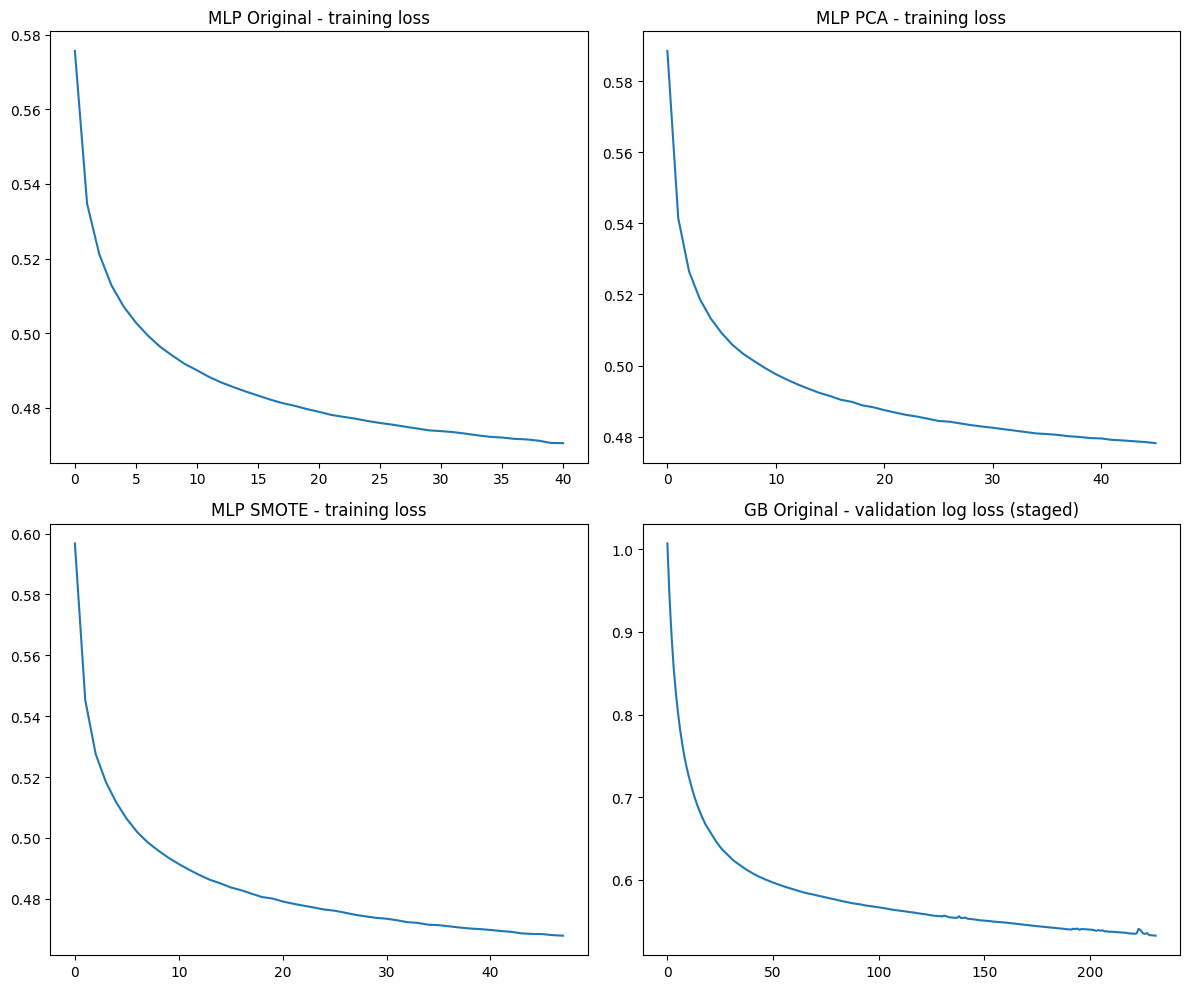

Saved training curves to training_curves.png


In [15]:
# === Plot training curves: MLP loss curves and GB staged validation loss ===
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import log_loss

# Load info if not in memory
if 'mlp_orig_info' not in globals() and os.path.exists("mlp_orig_info.pkl"):
    mlp_orig_info = joblib.load("mlp_orig_info.pkl")
if 'mlp_pca_info' not in globals() and os.path.exists("mlp_pca_info.pkl"):
    mlp_pca_info = joblib.load("mlp_pca_info.pkl")
if 'mlp_smote_info' not in globals() and os.path.exists("mlp_smote_info.pkl"):
    mlp_smote_info = joblib.load("mlp_smote_info.pkl")

# Load gb models if not in memory
if 'gb_orig' not in globals() and os.path.exists("gb_original.pkl"):
    gb_orig = joblib.load("gb_original.pkl")
if 'gb_smote' not in globals() and os.path.exists("gb_smote.pkl"):
    gb_smote = joblib.load("gb_smote.pkl")

# Prepare a small validation set for staged GB loss (use a subset from training or reuse previously saved X_val)
# If X_val not available, sample from X_train_orig (safe if memory allows)
try:
    X_train_orig = X_train_orig
    y_train = y_train
except NameError:
    X_train_orig = pd.read_csv("X_train_final.csv")
    y_train = pd.read_csv("y_train.csv").iloc[:,0]

from sklearn.model_selection import train_test_split
X_val, _, y_val, _ = train_test_split(X_train_orig, y_train, test_size=0.95, stratify=y_train, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

# MLP loss curves (training)
if 'mlp_orig_info' in globals() and mlp_orig_info.get("loss_curve") is not None:
    axes[0].plot(mlp_orig_info["loss_curve"])
    axes[0].set_title("MLP Original - training loss")
else:
    axes[0].text(0.5,0.5,"No loss_curve available", ha='center')

if 'mlp_pca_info' in globals() and mlp_pca_info.get("loss_curve") is not None:
    axes[1].plot(mlp_pca_info["loss_curve"])
    axes[1].set_title("MLP PCA - training loss")
else:
    axes[1].text(0.5,0.5,"No loss_curve available", ha='center')

if 'mlp_smote_info' in globals() and mlp_smote_info.get("loss_curve") is not None:
    axes[2].plot(mlp_smote_info["loss_curve"])
    axes[2].set_title("MLP SMOTE - training loss")
else:
    axes[2].text(0.5,0.5,"No loss_curve available", ha='center')

# GB staged validation log loss (if supported)
try:
    gb_vals = []
    for y_proba in gb_orig.staged_predict_proba(X_val):
        gb_vals.append(log_loss(y_val, y_proba))
    axes[3].plot(gb_vals)
    axes[3].set_title("GB Original - validation log loss (staged)")
except Exception as e:
    axes[3].text(0.02,0.5, f"GB staged not available: {e}", fontsize=9)
    axes[3].set_title("GB staged loss not available")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()
print("Saved training curves to training_curves.png")


In [16]:
# === Save validation metrics summary ===
import joblib, pandas as pd, numpy as np

VALIDATION_METRICS = "validation_metrics.csv"

rows = []
# For MLPs we stored info objects with loss_curve and maybe validation_scores
for name, info in [("MLP_orig", globals().get("mlp_orig_info")), ("MLP_pca", globals().get("mlp_pca_info")), ("MLP_smote", globals().get("mlp_smote_info"))]:
    if info is None:
        rows.append({"model": name, "val_score_mean": None, "n_epochs": None})
    else:
        val_scores = info.get("validation_scores")
        rows.append({"model": name, "val_score_mean": float(np.mean(val_scores)) if val_scores else None, "n_epochs": len(info.get("loss_curve", []))})

# GB info files
if os.path.exists("gb_orig_info.pkl"):
    gb_orig_info = joblib.load("gb_orig_info.pkl")
    rows.append({"model": "GB_orig", "val_score_mean": None, "n_iters": gb_orig_info.get("n_iter")})
else:
    rows.append({"model":"GB_orig", "val_score_mean": None, "n_iters": getattr(globals().get("gb_orig"), "n_iter_", None)})

if os.path.exists("gb_smote_info.pkl"):
    gb_smote_info = joblib.load("gb_smote_info.pkl")
    rows.append({"model": "GB_smote", "val_score_mean": None, "n_iters": gb_smote_info.get("n_iter")})
else:
    rows.append({"model":"GB_smote", "val_score_mean": None, "n_iters": getattr(globals().get("gb_smote"), "n_iter_", None)})

pd.DataFrame(rows).to_csv(VALIDATION_METRICS, index=False)
print("Saved validation metrics to", VALIDATION_METRICS)


Saved validation metrics to validation_metrics.csv
